**Lu-177: Comparing S-value equations/values**

Formulating Lu-177 S-values as functions of tumor radius and mass

In [1]:
# Import necessary libraries
import pycno
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

Cellular level tumor details

In [2]:
singleCell_ten_umDiam = 10e-6
singleCell_twenty_umDiam = 20e-6
singleCell_fourteen_umDiam = 14e-6

density_tumour = 1.05  # g/mL

# Convert diameters to masses (cm units for volume in mL)
tenUMcell_mass = 4/3 * np.pi * ((singleCell_ten_umDiam/2 * 1e2)**3) * density_tumour
twentyUMcell_mass = 4/3 * np.pi * ((singleCell_twenty_umDiam/2 * 1e2)**3) * density_tumour
fourteenUMcell_mass = 4/3 * np.pi * ((singleCell_fourteen_umDiam/2 * 1e2)**3) * density_tumour

print(f"A single, spherical tumour cell translates to a mass of:\n~{tenUMcell_mass:.2e} - {twentyUMcell_mass:.2e} g")

A single, spherical tumour cell translates to a mass of:
~5.50e-10 - 4.40e-09 g


In [3]:
# Beta decay ranges
maxBetaRange = 2e-3  # meters
meanBetaRange = 0.28e-3  # meters

maxBetaRange_fourMMcell_mass = 4/3 * np.pi * ((maxBetaRange*2/2 *1e2)**3) * density_tumour
meanBetaRange_mass = 4/3 * np.pi * ((meanBetaRange*2 *1e2)**3) * density_tumour

print(f"Beta decay starts being emitted beyond cells of ~{maxBetaRange_fourMMcell_mass:.2e} g")

Beta decay starts being emitted beyond cells of ~3.52e-02 g


**Zaid et al. (2025); Olguin et al. (2020)**

In [4]:
N = 10000

# Zaid et al. (2025)
zaid_mass = np.logspace(np.log10(1e-10), np.log10(15), N)
zaid_sValue = 83 * (zaid_mass)**-0.99

# Olguin et al. (2022)
olguin_mass = np.logspace(np.log10(0.0043145), np.log10(931.922), N)
olguin_Lu177_sValue = 79.6 * (olguin_mass/density_tumour)**-0.985

olguin_radius = np.logspace(np.log10(1e-3), np.log10(6e-2), N)
olguin_Lu177_sValue_radius = 5.4e-12 * (olguin_radius*1e2)**(-2.955) * 1e9 * 3600  # convert from Gy/Bq/s to mGy/MBq/h

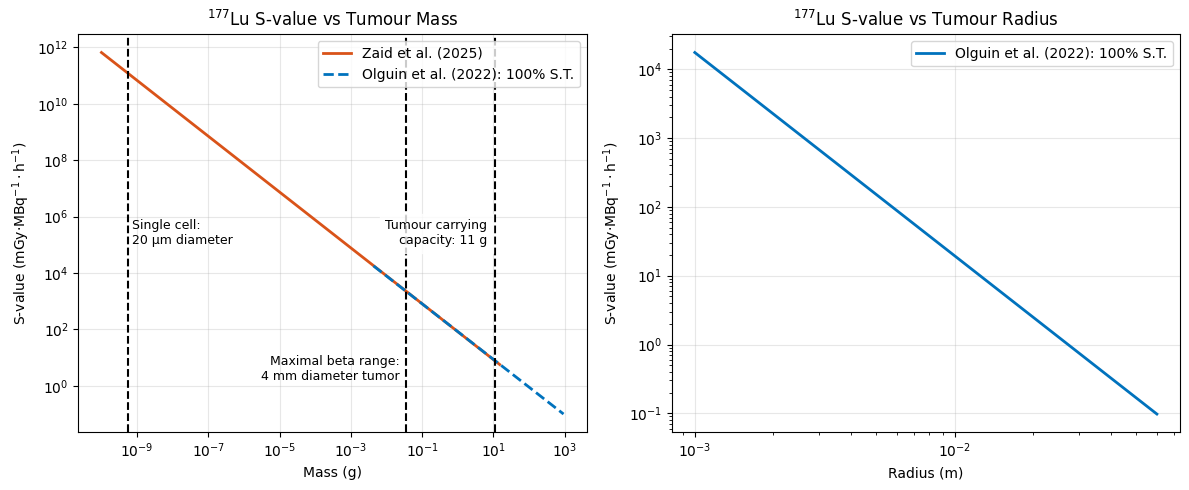

In [5]:
# Ploting S-values as a function of mass and radius
plotColor = [
    (0.0000, 0.4470, 0.7410),  # blue for Olguin
    (0.8500, 0.3250, 0.0980),  # orange for Zaid
    (0.9290, 0.6940, 0.1250),  # yellow for Hindie
    (0.4940, 0.1840, 0.5560)   # purple for Lee
]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# -----------------------------
# Left plot: S-value vs Mass
# -----------------------------
ax = axes[0]

ax.loglog(zaid_mass, zaid_sValue, linewidth=2, color=plotColor[1], label='Zaid et al. (2025)')
ax.loglog(olguin_mass, olguin_Lu177_sValue, linewidth=2, linestyle='--', color=plotColor[0], label='Olguin et al. (2022): 100% S.T.')

# Vertical lines
ax.axvline(maxBetaRange_fourMMcell_mass, color='k', linestyle='--')
ax.axvline(tenUMcell_mass, color='k', linestyle='--')
ax.axvline(11, color='k', linestyle='--')

# Text beside vertical lines
ymin, ymax = ax.get_ylim()

# Max beta range
ax.text(maxBetaRange_fourMMcell_mass*0.65, 10**((np.log10(ymin) + np.log10(ymax))/10),
        'Maximal beta range:\n4 mm diameter tumor',
        ha='right', va='top', color='k', fontsize=9)

# Single cell
ax.text(tenUMcell_mass*1.35, 10**((np.log10(ymin) + np.log10(ymax))/2),
        'Single cell:\n20 µm diameter',
        ha='left', va='center', color='k', fontsize=9)

# Tumour carrying capacity
ax.text(11*0.62, 10**((np.log10(ymin) + np.log10(ymax))/2),
        'Tumour carrying\ncapacity: 11 g',
        ha='right', va='center',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.8),
        fontsize=9)

ax.set_xlabel("Mass (g)")
ax.set_ylabel(r"S-value (mGy$\cdot$MBq$^{-1}\cdot$h$^{-1}$)")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.set_title("$^{177}$Lu S-value vs Tumour Mass")

# -----------------------------
# Right plot: S-value vs Radius
# -----------------------------
ax2 = axes[1]
ax2.loglog(olguin_radius, olguin_Lu177_sValue_radius, color=plotColor[0], linewidth=2, label='Olguin et al. (2022): 100% S.T.')

ax2.set_xlabel("Radius (m)")
ax2.set_ylabel(r"S-value (mGy$\cdot$MBq$^{-1}\cdot$h$^{-1}$)")
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_title("$^{177}$Lu S-value vs Tumour Radius")

plt.tight_layout()
plt.show()

**Lee (2022): micro-scale dosimetry**

A linear relationship is shown between absorbed dose and tumour radius for $^{177}\text{Lu}$ from 14 to 100 um. Given the data for 225Ac (alpha decay), an asymtpote for absorbed dose exist near the maximal decay range (~85 um). A similar plauteau likely exists for 177Lu near ~2.0 mm

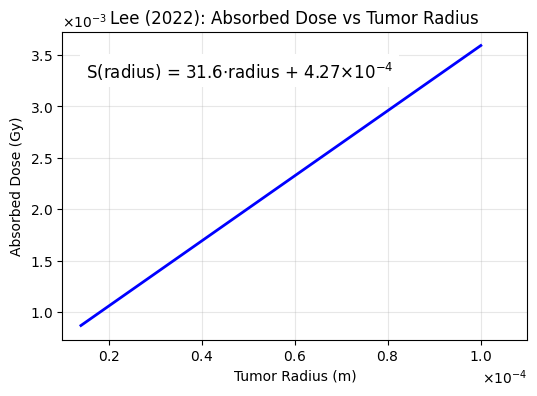

In [6]:
r1, d1 = 14.050689029546877e-6, 0.0008709750727402162
r2, d2 = 99.4642744047597e-6, 0.003572537171085721

slope = (d2 - d1) / (r2 - r1)
intercept = d1 - slope * r1

Lee_radius_tumor_m = np.linspace(14e-6, 100e-6, 10000)

# Lee (2022) regression line (developed between ~ 15 - 100 um diameter)
Lee_absorbedDose_Gy = slope * Lee_radius_tumor_m + intercept

plt.figure(2, figsize=(6,4))
plt.plot(Lee_radius_tumor_m, Lee_absorbedDose_Gy, 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel("Tumor Radius (m)")
plt.ylabel("Absorbed Dose (Gy)")
plt.title("Lee (2022): Absorbed Dose vs Tumor Radius")
plt.xlim([10e-6, 110e-6])

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))

ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

ax.text(0.05, 0.85,
        r"S(radius) = 31.6$\cdot$radius + 4.27$\times10^{-4}$",
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(facecolor='white', edgecolor='none'));

Lee derivation: S-value as a function of mass

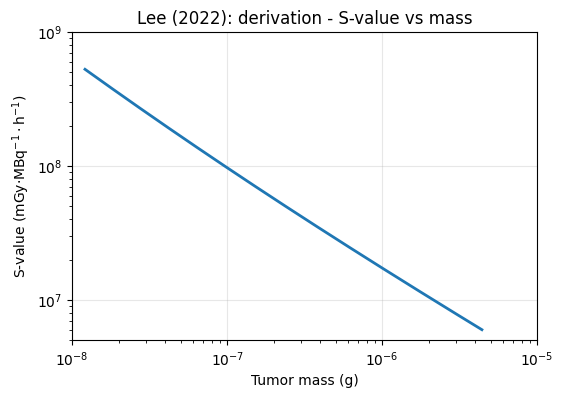

In [7]:
Lee_derivation_tumour_mass = np.logspace(np.log10(1.21e-8), np.log10(4.40e-6), 10000)

Lee_derivation_sValue_mGyMBqH = (
    5.27e-2 * (4*np.pi*density_tumour/3e-6)**(2/3) * Lee_derivation_tumour_mass**(-2/3)
    + 7.13e-7 * (4*np.pi*density_tumour/3e-6) * Lee_derivation_tumour_mass**(-1))

plt.figure(3, figsize=(6,4))
plt.clf()

plt.loglog(Lee_derivation_tumour_mass, Lee_derivation_sValue_mGyMBqH, linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlim([1e-8, 1e-5])
plt.ylim([5e6, 1e9])

plt.ylabel(r"S-value (mGy$\cdot$MBq$^{-1}\cdot$h$^{-1}$)")
plt.xlabel("Tumor mass (g)")
plt.title("Lee (2022): derivation - S-value vs mass")

plt.show()

**Hindie et al. (2016)**: dose deposits from various micrometases

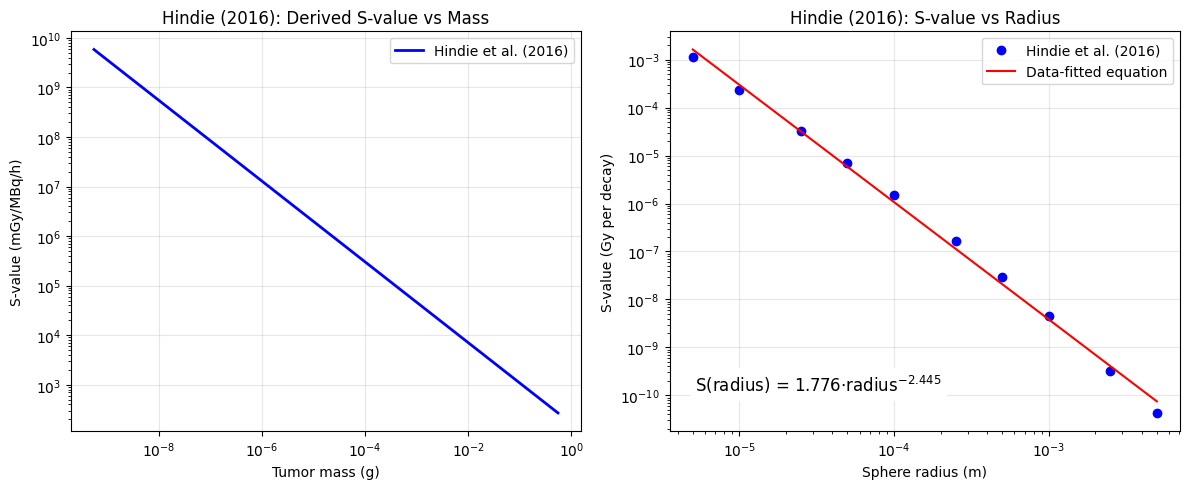

In Hindie (2016), the relationship between S-value as a function of radius is given as:
   S-value(radius) = 1.776e-16 * [radius_tumor (m)]^(-2.445),
where S-value is in units of Gy per decay


In [8]:
hindie_sphereDiameter_um = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000])  # um
hindie_sphereRadius_m = hindie_sphereDiameter_um/2 * 1e-6
hindie_Lu_dose_Gy = np.array([1.11e-3, 2.33e-4, 3.18e-5, 6.93e-6, 1.48e-6, 1.69e-7, 2.94e-8, 4.54e-9, 3.29e-10, 4.30e-11])

# S-value formula as a function of radius (m)
hindie_radius_valid = np.linspace(hindie_sphereRadius_m[0], hindie_sphereRadius_m[-1], 10000)
hindie_formula_sValue = 1.776e-16 * hindie_radius_valid**-2.445

# S-value formula derived as a function of mass (g)
hindie_derivation_mass_g = np.logspace(np.log10(5.5e-10), np.log10(0.55), 10000)
hindie_derivation_sValue_mGyMBqH = 6.39e-4 * (3e-6*hindie_derivation_mass_g/(4*np.pi*density_tumour))**(-0.815)

# -----------------------------
# 1-row, 2-column subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# -----------------------------
# Left plot: S-value vs Mass
ax = axes[0]
ax.loglog(hindie_derivation_mass_g, hindie_derivation_sValue_mGyMBqH, 'b-', linewidth=2, label='Hindie et al. (2016)')
ax.set_xlabel("Tumor mass (g)")
ax.set_ylabel("S-value (mGy/MBq/h)")
ax.set_title("Hindie (2016): Derived S-value vs Mass")
ax.grid(True, alpha=0.3)
ax.legend()

# -----------------------------
# Right plot: S-value vs Radius
ax2 = axes[1]
ax2.loglog(hindie_sphereRadius_m, hindie_Lu_dose_Gy, 'bo', label='Hindie et al. (2016)')
ax2.loglog(hindie_radius_valid, hindie_formula_sValue, 'r-', label='Data-fitted equation')

ax2.set_xlabel("Sphere radius (m)")
ax2.set_ylabel("S-value (Gy per decay)")
ax2.set_title("Hindie (2016): S-value vs Radius")
ax2.grid(True, alpha=0.3)
ax2.legend()

# Add equation textbox in lower left corner
ax2.text(0.05, 0.1,
         r"S(radius) = 1.776$\cdot$radius$^{-2.445}$",
         transform=ax2.transAxes,
         fontsize=12,
         bbox=dict(facecolor='white', edgecolor='none'))

plt.tight_layout()
plt.show()

# Print equation in console
print('In Hindie (2016), the relationship between S-value as a function of radius is given as:\n'
      '   S-value(radius) = 1.776e-16 * [radius_tumor (m)]^(-2.445),\n'
      'where S-value is in units of Gy per decay')


**Hindie derivation:** absorbed dose as a function of mass/radius

In [9]:
# Data reported from 5 - 5000 um -> 5.5e-10 - 0.55 g
hindie_derivation_mass_g = np.logspace(np.log10(5.5e-10), np.log10(0.55), 10000)
hindie_derivation_sValue_mGyMBqH = 6.39e-4 * (3e-6*hindie_derivation_mass_g/(4*np.pi*density_tumour))**(-0.815)

hindie_radiusValid = np.linspace(10e-6, 10000e-6, N);
hindie_sValue_r_mGyMBqH = 6.394e-4 * hindie_radiusValid**-2.445;


**Comparing all S-value equations**

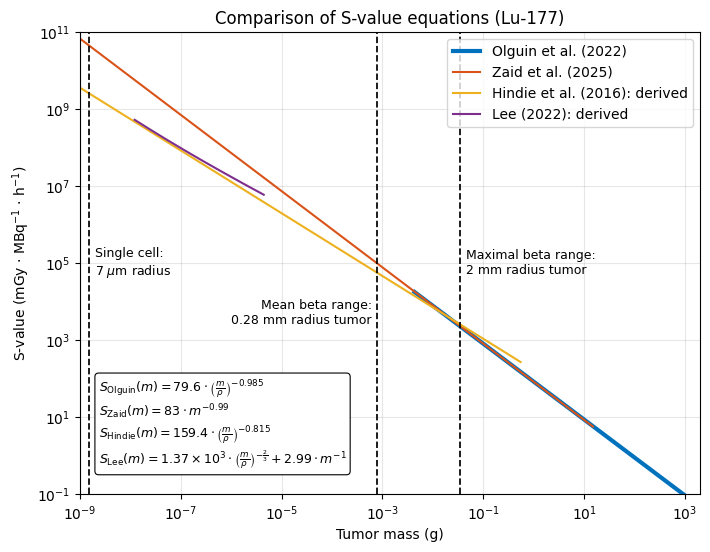

The Hindie et al. (2016) and Lee (2022) relationships are largely consistent.
 To evaluate their similarity, we plot the ratio between the two:


In [10]:
plotColor = [
    (0.0000, 0.4470, 0.7410),  # blue
    (0.8500, 0.3250, 0.0980),  # orange
    (0.9290, 0.6940, 0.1250),  # yellow
    (0.4940, 0.1840, 0.5560)   # purple
]
    
plt.figure(5, figsize=(8,6))
# Olguin
plt.loglog(
    olguin_mass,
    olguin_Lu177_sValue,
    linestyle="-",
    color=plotColor[0],
    linewidth=3,
    label="Olguin et al. (2022)")

# Zaid
plt.loglog(
    zaid_mass,
    zaid_sValue,
    linestyle="-",
    color=plotColor[1],
    linewidth=1.5,
    label="Zaid et al. (2025)")

# Hindie
plt.loglog(
    hindie_derivation_mass_g,
    hindie_derivation_sValue_mGyMBqH,
    linestyle="-",
    color=plotColor[2],
    linewidth=1.5,
    label="Hindie et al. (2016): derived")

# Lee
plt.loglog(
    Lee_derivation_tumour_mass,
    Lee_derivation_sValue_mGyMBqH,
    linestyle="-",
    color=plotColor[3],
    linewidth=1.5,
    label="Lee (2022): derived")

plt.grid(True, which="both", alpha=0.3)
plt.xlabel("Tumor mass (g)")
plt.ylabel(r"S-value (mGy $\cdot$ MBq$^{-1}$ $\cdot$ h$^{-1}$)")
plt.title("Comparison of S-value equations (Lu-177)")

plt.xlim([1e-9, 2e3])
plt.ylim([1e-1, 1e11])

ax = plt.gca()

# -----------------------------
# Vertical lines + labels
# -----------------------------
plt.axvline(fourteenUMcell_mass, color="k", linestyle="--", linewidth=1.25)
plt.axvline(maxBetaRange_fourMMcell_mass, color="k", linestyle="--", linewidth=1.25)
plt.axvline(meanBetaRange_mass, color="k", linestyle="--", linewidth=1.25)

# Text label placement (log axes -> multiply/divide works better than add/subtract)
y_label_high = 1e5
y_label_low  = 5e3

# Single cell label
ax.text(
    fourteenUMcell_mass * 1.3,
    y_label_high,
    r"Single cell:" "\n" r"7 $\mu$m radius",
    fontsize=9,
    ha="left",
    va="center"
)

# Max beta range label
ax.text(
    maxBetaRange_fourMMcell_mass * 1.3,
    y_label_high,
    "Maximal beta range:\n2 mm radius tumor",
    fontsize=9,
    ha="left",
    va="center"
)

# Mean beta range label
ax.text(
    meanBetaRange_mass * 0.8,
    y_label_low,
    "Mean beta range:\n0.28 mm radius tumor",
    fontsize=9,
    ha="right",
    va="center"
)

# -----------------------------
# Equation annotation box
# -----------------------------
eqnStr = (
    r"$S_{\mathrm{Olguin}}(m) = 79.6 \cdot \left(\frac{m}{\rho}\right)^{-0.985}$" "\n"
    r"$S_{\mathrm{Zaid}}(m) = 83 \cdot m^{-0.99}$" "\n"
    r"$S_{\mathrm{Hindie}}(m) = 159.4 \cdot \left(\frac{m}{\rho}\right)^{-0.815}$" "\n"
    r"$S_{\mathrm{Lee}}(m) = 1.37 \times 10^3 \cdot \left(\frac{m}{\rho}\right)^{-\frac{2}{3}} + 2.99 \cdot m^{-1}$"
)

ax.text(
    0.03, 0.05, eqnStr,
    transform=ax.transAxes,   # normalized coords (0-1), like MATLAB annotation
    fontsize=9,
    verticalalignment="bottom",
    horizontalalignment="left",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=0.8)
)

plt.legend()
plt.show()

print('The Hindie et al. (2016) and Lee (2022) relationships are largely consistent.\n',
'To evaluate their similarity, we plot the ratio between the two:')

Comparing the Hindie and Lee S-values

Across the Lee (2022) tumor mass range, the two equations are less than 1.6x different.
 Given this similarity, we assume the Hindie is representative of the micro-scale tumor mass S-values


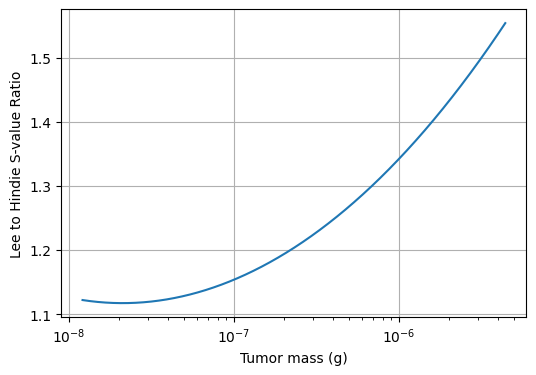

In [11]:
hindie_derivation_sValue_mGyMBqH_leeRange = (
    6.39e-4 * (3e-6 * Lee_derivation_tumour_mass / (4 * np.pi * density_tumour))**(-0.815))

lee_hindie_ratio = Lee_derivation_sValue_mGyMBqH / hindie_derivation_sValue_mGyMBqH_leeRange

# -----------------------------
# Plot
# -----------------------------
plt.figure(6, figsize=(6,4))
plt.clf()

plt.semilogx(
    Lee_derivation_tumour_mass,
    lee_hindie_ratio,
    linewidth=1.5)
    
plt.grid(True)
plt.ylabel("Lee to Hindie S-value Ratio")
plt.xlabel("Tumor mass (g)")

print('Across the Lee (2022) tumor mass range, the two equations are less than 1.6x different.\n',
    'Given this similarity, we assume the Hindie is representative of the micro-scale tumor mass S-values')

**Creating a single formalism from micro- to macroscopic tumors**

To link the S-values at the micro- and macro-scale tumor sizes, we use the Hindie equation to inform the micro-scale and the Olguin equation to inform the macro-scale, and link them together using a logistic transition function 

In [12]:
# -----------------------------
# Smooth S-value formalism - mass
# -----------------------------

# Mass range
mass_smooth = np.logspace(-10, 3, 4000)  # 10^-10 to 10^3 g

# Constants
density_tumour = 1.05

# Transition masses
m12 = 1.9131414420271935e-02  # Hindie ↔ Olguin

k = 4  # smoothness (increase for sharper transitions)

# Component functions
Hindie = lambda x: 6.39e-4 * (3e-6 * x / (4 * np.pi * density_tumour))**(-0.815)
Olguin = lambda x: 79.6 * (x / density_tumour)**(-0.985)

# Logistic transition functions
T12 = 1 / (1 + (m12 / mass_smooth)**k)

# Final smooth S-value
sValue_smooth = (1 - T12) * Hindie(mass_smooth) + T12 * Olguin(mass_smooth)

In [13]:
# ------------------------------
# Smooth s-value formalism - radius
# ------------------------------

# Smooth radius range
# tumorRadius_range = np.linspace(singleCell_ten_umDiam/2, 50e-3, N);
tumorRadius_range = np.linspace(singleCell_ten_umDiam/2, 60e-3, N*100);

# tumorRadius_range = np.linspace(singleCell_ten_umDiam/2, 100, N*100);
radius_smooth = tumorRadius_range 

# Transition radius
r12 = 1.59e-3  # m: Hindie ↔ Olguin
k = 4          # smoothness parameter

# Component functions
Olguin_radius = lambda x: 19.44 * (x*1e2)**-2.955
Hindie_radius = lambda x: 6.394e-4 * x**-2.445

# Logistic transition function
T12_radius = 1 / (1 + (r12 / radius_smooth)**k)

# Final smooth S-value
sValue_smooth_radius = (1 - T12_radius)*Hindie_radius(radius_smooth) + T12_radius*Olguin_radius(radius_smooth)

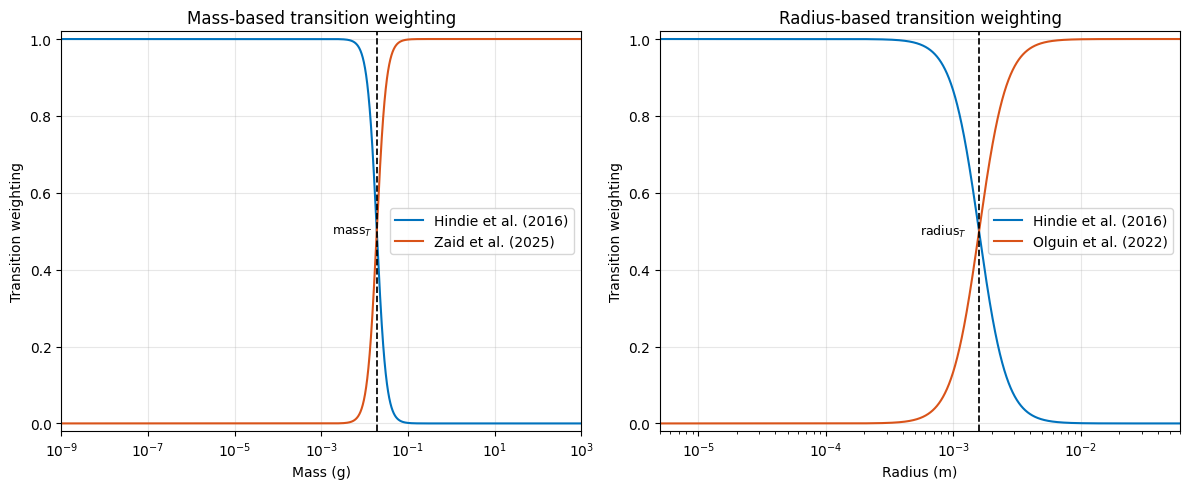

In [14]:
# -----------------------------
# Plot transition weighting
# -----------------------------

# Left plot: mass-based transition weighting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mass-based (left)
ax = axes[0]
ax.semilogx(mass_smooth, (1 - T12), color=plotColor[0], linewidth=1.5, label='Hindie et al. (2016)')
ax.semilogx(mass_smooth, T12, color=plotColor[1], linewidth=1.5, label='Zaid et al. (2025)')
ax.axvline(m12, color='k', linestyle='--', linewidth=1.25)
ax.text(m12*0.8, 0.5, 'mass$_T$', ha='right', va='center', fontsize=9)
ax.set_xlabel("Mass (g)")
ax.set_ylabel("Transition weighting")
ax.set_xlim([1e-9, 1e3])
ax.set_ylim([-0.02, 1.02])
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title("Mass-based transition weighting")

# -----------------------------
# Right plot: radius-based transition weighting
ax2 = axes[1]

ax2.semilogx(tumorRadius_range, (1 - T12_radius), color=plotColor[0], linewidth=1.5, label='Hindie et al. (2016)')
ax2.semilogx(tumorRadius_range, T12_radius, color=plotColor[1], linewidth=1.5, label='Olguin et al. (2022)')

# Vertical line at transition radius
ax2.axvline(r12, color='k', linestyle='--', linewidth=1.25)
ax2.text(r12*0.8, 0.5, 'radius$_T$', ha='right', va='center', fontsize=9)

ax2.set_xlabel("Radius (m)")
ax2.set_ylabel("Transition weighting")
ax2.set_xlim([tumorRadius_range[0], tumorRadius_range[-1]])
ax2.set_ylim([-0.02, 1.02])
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_title("Radius-based transition weighting")

plt.tight_layout()
plt.show()

Plotting the smooth, multi-scale curve against the data-informed relationships

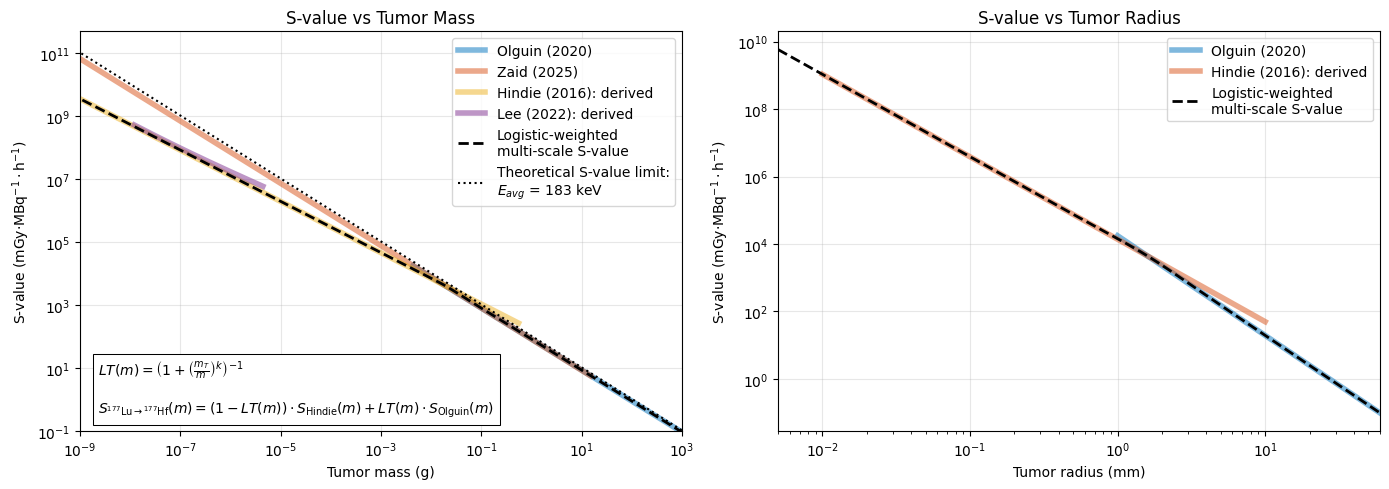

In [15]:
lineWidth_studies = 4
alphaVal = 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------
# Left: S-value vs tumor mass
ax = axes[0]

# Olguin
ax.loglog(olguin_mass, olguin_Lu177_sValue,
          linestyle="-", color=(*plotColor[0], alphaVal),
          linewidth=lineWidth_studies, label="Olguin (2020)")

# Zaid
ax.loglog(zaid_mass, zaid_sValue,
          linestyle="-", color=(*plotColor[1], alphaVal),
          linewidth=lineWidth_studies, label="Zaid (2025)")

# Hindie
ax.loglog(hindie_derivation_mass_g, hindie_derivation_sValue_mGyMBqH,
          linestyle="-", color=(*plotColor[2], alphaVal),
          linewidth=lineWidth_studies, label="Hindie (2016): derived")

# Lee
ax.loglog(Lee_derivation_tumour_mass, Lee_derivation_sValue_mGyMBqH,
          linestyle="-", color=(*plotColor[3], alphaVal),
          linewidth=lineWidth_studies, label="Lee (2022): derived")

# Smoothed logistic-weighted curve
ax.loglog(mass_smooth, sValue_smooth, "k--", linewidth=2,
          label="Logistic-weighted\nmulti-scale S-value")

# Theoretical S-value limits
# ax.loglog(mass_smooth, (576.72 * 0.14735)/mass_smooth, "k:", linewidth=1.5, label="Theoretical S-value limit")
ax.loglog(mass_smooth, (576.72 * 0.183)/mass_smooth, "k:", linewidth=1.5, label="Theoretical S-value limit:\n$E_{avg}$ = 183 keV")

ax.set_xlabel("Tumor mass (g)")
ax.set_ylabel(r"S-value (mGy$\cdot$MBq$^{-1}\cdot$h$^{-1}$)")
ax.set_xlim([1e-9, 1e3])
ax.set_ylim([1e-1, 5e11])
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title("S-value vs Tumor Mass")

# Equation annotation
eqnStr = (
    r"$LT(m) = \left( 1 + \left( \frac{m_T}{m} \right)^k \right)^{-1}$"
    "\n\n"
    r"$S_{^{177}\mathrm{Lu}\rightarrow^{177}\mathrm{Hf}}(m) = "
    r"(1-LT(m)) \cdot S_{\mathrm{Hindie}}(m) + LT(m) \cdot S_{\mathrm{Olguin}}(m)$"
)
ax.text(0.03, 0.03, eqnStr, transform=ax.transAxes,
        fontsize=10, va="bottom", ha="left",
        bbox=dict(facecolor="white", edgecolor="black", linewidth=0.75))

# -----------------------------
# Right: S-value vs tumor radius
ax2 = axes[1]

# Olguin radius
ax2.loglog(olguin_radius*1e3, olguin_Lu177_sValue_radius,
           linestyle="-", color=(*plotColor[0], alphaVal),
           linewidth=lineWidth_studies, label="Olguin (2020)")

# Hindie radius
ax2.loglog(hindie_radiusValid*1e3, hindie_sValue_r_mGyMBqH,
           linestyle="-", color=(*plotColor[1], alphaVal),
           linewidth=lineWidth_studies, label="Hindie (2016): derived")

# Smoothed logistic-weighted
ax2.loglog(radius_smooth*1e3, sValue_smooth_radius,
           "k--", linewidth=2, label="Logistic-weighted\nmulti-scale S-value")

ax2.set_xlabel("Tumor radius (mm)")
ax2.set_ylabel(r"S-value (mGy$\cdot$MBq$^{-1}\cdot$h$^{-1}$)")
ax2.set_xlim([radius_smooth[0]*1e3, radius_smooth[-1]*1e3])
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_title("S-value vs Tumor Radius")

plt.tight_layout()
plt.show()


**Energy deposition as a function of tumor radius** 

In [16]:
# Convert S-value to a single decay
numDecay = 1e6 * 3600; # MBq per hour to Bq/s (1 decay)

# convert from mGy to Gy; normalize to number of decays
sValue_smooth_r_perDecay = sValue_smooth_radius * 1e-3 / numDecay; 

Convert from dose per decay (S-value, Gy) to absorbed energy per decay

In [17]:
# Dose (Gy) = E_abs (J) / mass (kg)
# sValue(m) = Dose / Activity
# Assuming 1 decay (activity):
#   sValue(m) = E_abs / mass
#   E_abs = sValue(m) * mass

# Constants
pi = np.pi
density_kg_m = 1030; # kg/m^; Olguin et al. (2022), 100% S.T. tumor density

tumorMass_conversion = (4/3) * pi * radius_smooth**3 * density_kg_m

E_abs = sValue_smooth_r_perDecay * (tumorMass_conversion)


Lu-177 energy emission

In [33]:
# Maximal energy emitted by Lu-177
Lu177_maxEnergy = 0.497; # MeV

# Lu177_meanEnergy = 0.149; # MeV; Beta decay only -> PMID: 32819499
Lu177_meanEnergy_electron = 0.1479; # MeV; PMID: 19285593 (search Lu-177)
Lu177_meanEnergy_photon = 0.0351; # MeV; PMID: 19285593 (search Lu-177)
Lu177_meanEnergy_total = Lu177_meanEnergy_electron + Lu177_meanEnergy_photon

# Converting from MeV to Joules
MeV_to_J = 1.60e-13
Lu177_depositFraction = E_abs/MeV_to_J # plotting emitted energy

Lu-177: energy deposition per decay per radius

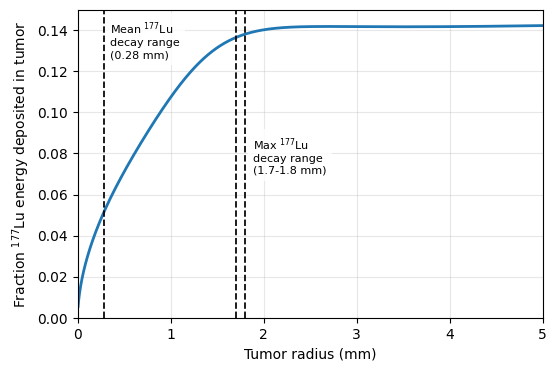

In [34]:
# Convert radius to mm
radius_smooth_mm = radius_smooth * 1e3  # m → mm

plt.figure(6, figsize=(6,4))
plt.clf()

# Plot Lu-177 deposited fraction
plt.plot(radius_smooth_mm, Lu177_depositFraction, linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlim([0, 5])
plt.ylim([0, 0.15])

plt.xlabel("Tumor radius (mm)")
plt.ylabel("Fraction $^{177}$Lu energy deposited in tumor")

# Vertical lines
meanDecay_mass = meanBetaRange * 1e3  # convert to mm
plt.axvline(meanDecay_mass, color='k', linestyle='--', linewidth=1.25)
plt.text(meanDecay_mass*1.25, 0.145,
         "Mean $^{177}$Lu\ndecay range\n(0.28 mm)",
         ha='left', va='top',
         fontsize=8,
         backgroundcolor='white',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

maxDecay_range_low = 1.7e-3 * 1e3  # mm
maxDecay_range_high = 1.8e-3 * 1e3  # mm
plt.axvline(maxDecay_range_low, color='k', linestyle='--', linewidth=1.25)
plt.axvline(maxDecay_range_high, color='k', linestyle='--', linewidth=1.25)
plt.text(maxDecay_range_high*1.05, max(Lu177_depositFraction)*0.5,
         "Max $^{177}$Lu\ndecay range\n(1.7-1.8 mm)",
         ha='left', va='center',
         fontsize=8,
         backgroundcolor='white',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))


# import matplotlib.pyplot as pltPy
plt.savefig("Lu177_depositFraction_vs_radius.pdf", format='pdf', bbox_inches='tight')
plt.show()